### Preparing the environnement

In [1]:
!nvidia-smi

Thu Jan  4 21:47:07 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

### Install YOLOv7

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Cloning the git repository of yolo

In [3]:
# clone YOLOv7 repository
%cd {HOME}
!git clone https://github.com/WongKinYiu/yolov7

# navigate to yolov7 directory and checkout u7 branch of YOLOv7 - this is hash of lates commit from u7 branch as of 12/21/2022
%cd {HOME}/yolov7
!git checkout 44f30af0daccb1a3baecc5d80eae22948516c579

/content
Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197
Receiving objects: 100% (1197/1197), 74.23 MiB | 26.24 MiB/s, done.
Resolving deltas: 100% (519/519), done.
/content/yolov7
Note: switching to '44f30af0daccb1a3baecc5d80eae22948516c579'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 44f30af u7 readme


### Install Requirements

In [4]:
%cd {HOME}/yolov7/seg
!pip install --upgrade pip
!pip install -r requirements.txt

/content/yolov7/seg
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.1.2
    Uninstalling pip-23.1.2:
      Successfully uninstalled pip-23.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.4.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.1 which is incompatible.
google-api-core 2.11.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=

### downloading the dataset 

In [6]:
%cd {HOME}/yolov7/seg



!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="bPdChgRsNYbOP3cjaigP")
project = rf.workspace("tcc-hugo").project("brain-tumor-detection-lovmz")
dataset = project.version(9).download("yolov8")


/content/yolov7/seg
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.3/158.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.1.1
    Uninstalling pyparsing-3.1.1:
      Successfully uninstalled pyparsing-3.1.1
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.8.1.78
    Uninstalling opencv-python-headless-4.8.1.78:
      Successfull

loading Roboflow workspace...
loading Roboflow project...
[WARNING] we noticed you are downloading a `yolov8` datasets but you don't have `ultralytics` installed. Roboflow `.deploy` supports only models trained with `ultralytics==8.0.196`, to intall it `pip install ultralytics==8.0.196`.



Extracting Dataset Version Zip to brain-tumor-detection-9 in yolov8:: 100%|██████████| 1680/1680 [00:00<00:00, 6761.16it/s]


### Custom Training

In [7]:
%cd {HOME}/yolov7/seg
!python segment/train.py --batch 16 \
 --epochs 10 \
 --data {dataset.location}/data.yaml \
 --weights $WEIGHTS_PATH \
 --device 0 \
 --name custom

/content/yolov7/seg
2024-01-04 21:48:05.981505: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-04 21:48:05.981562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-04 21:48:05.982918: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-01-04 21:48:07.051607: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
segment/train: weights=/content/yolov7/seg/yolov7-seg.pt, cfg=, data=/content/yolov7/seg/brain-tumor-detection-9/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=10, batch_size=16, imgsz=640, rect=False, resume=False

### evaluating the model on validation set

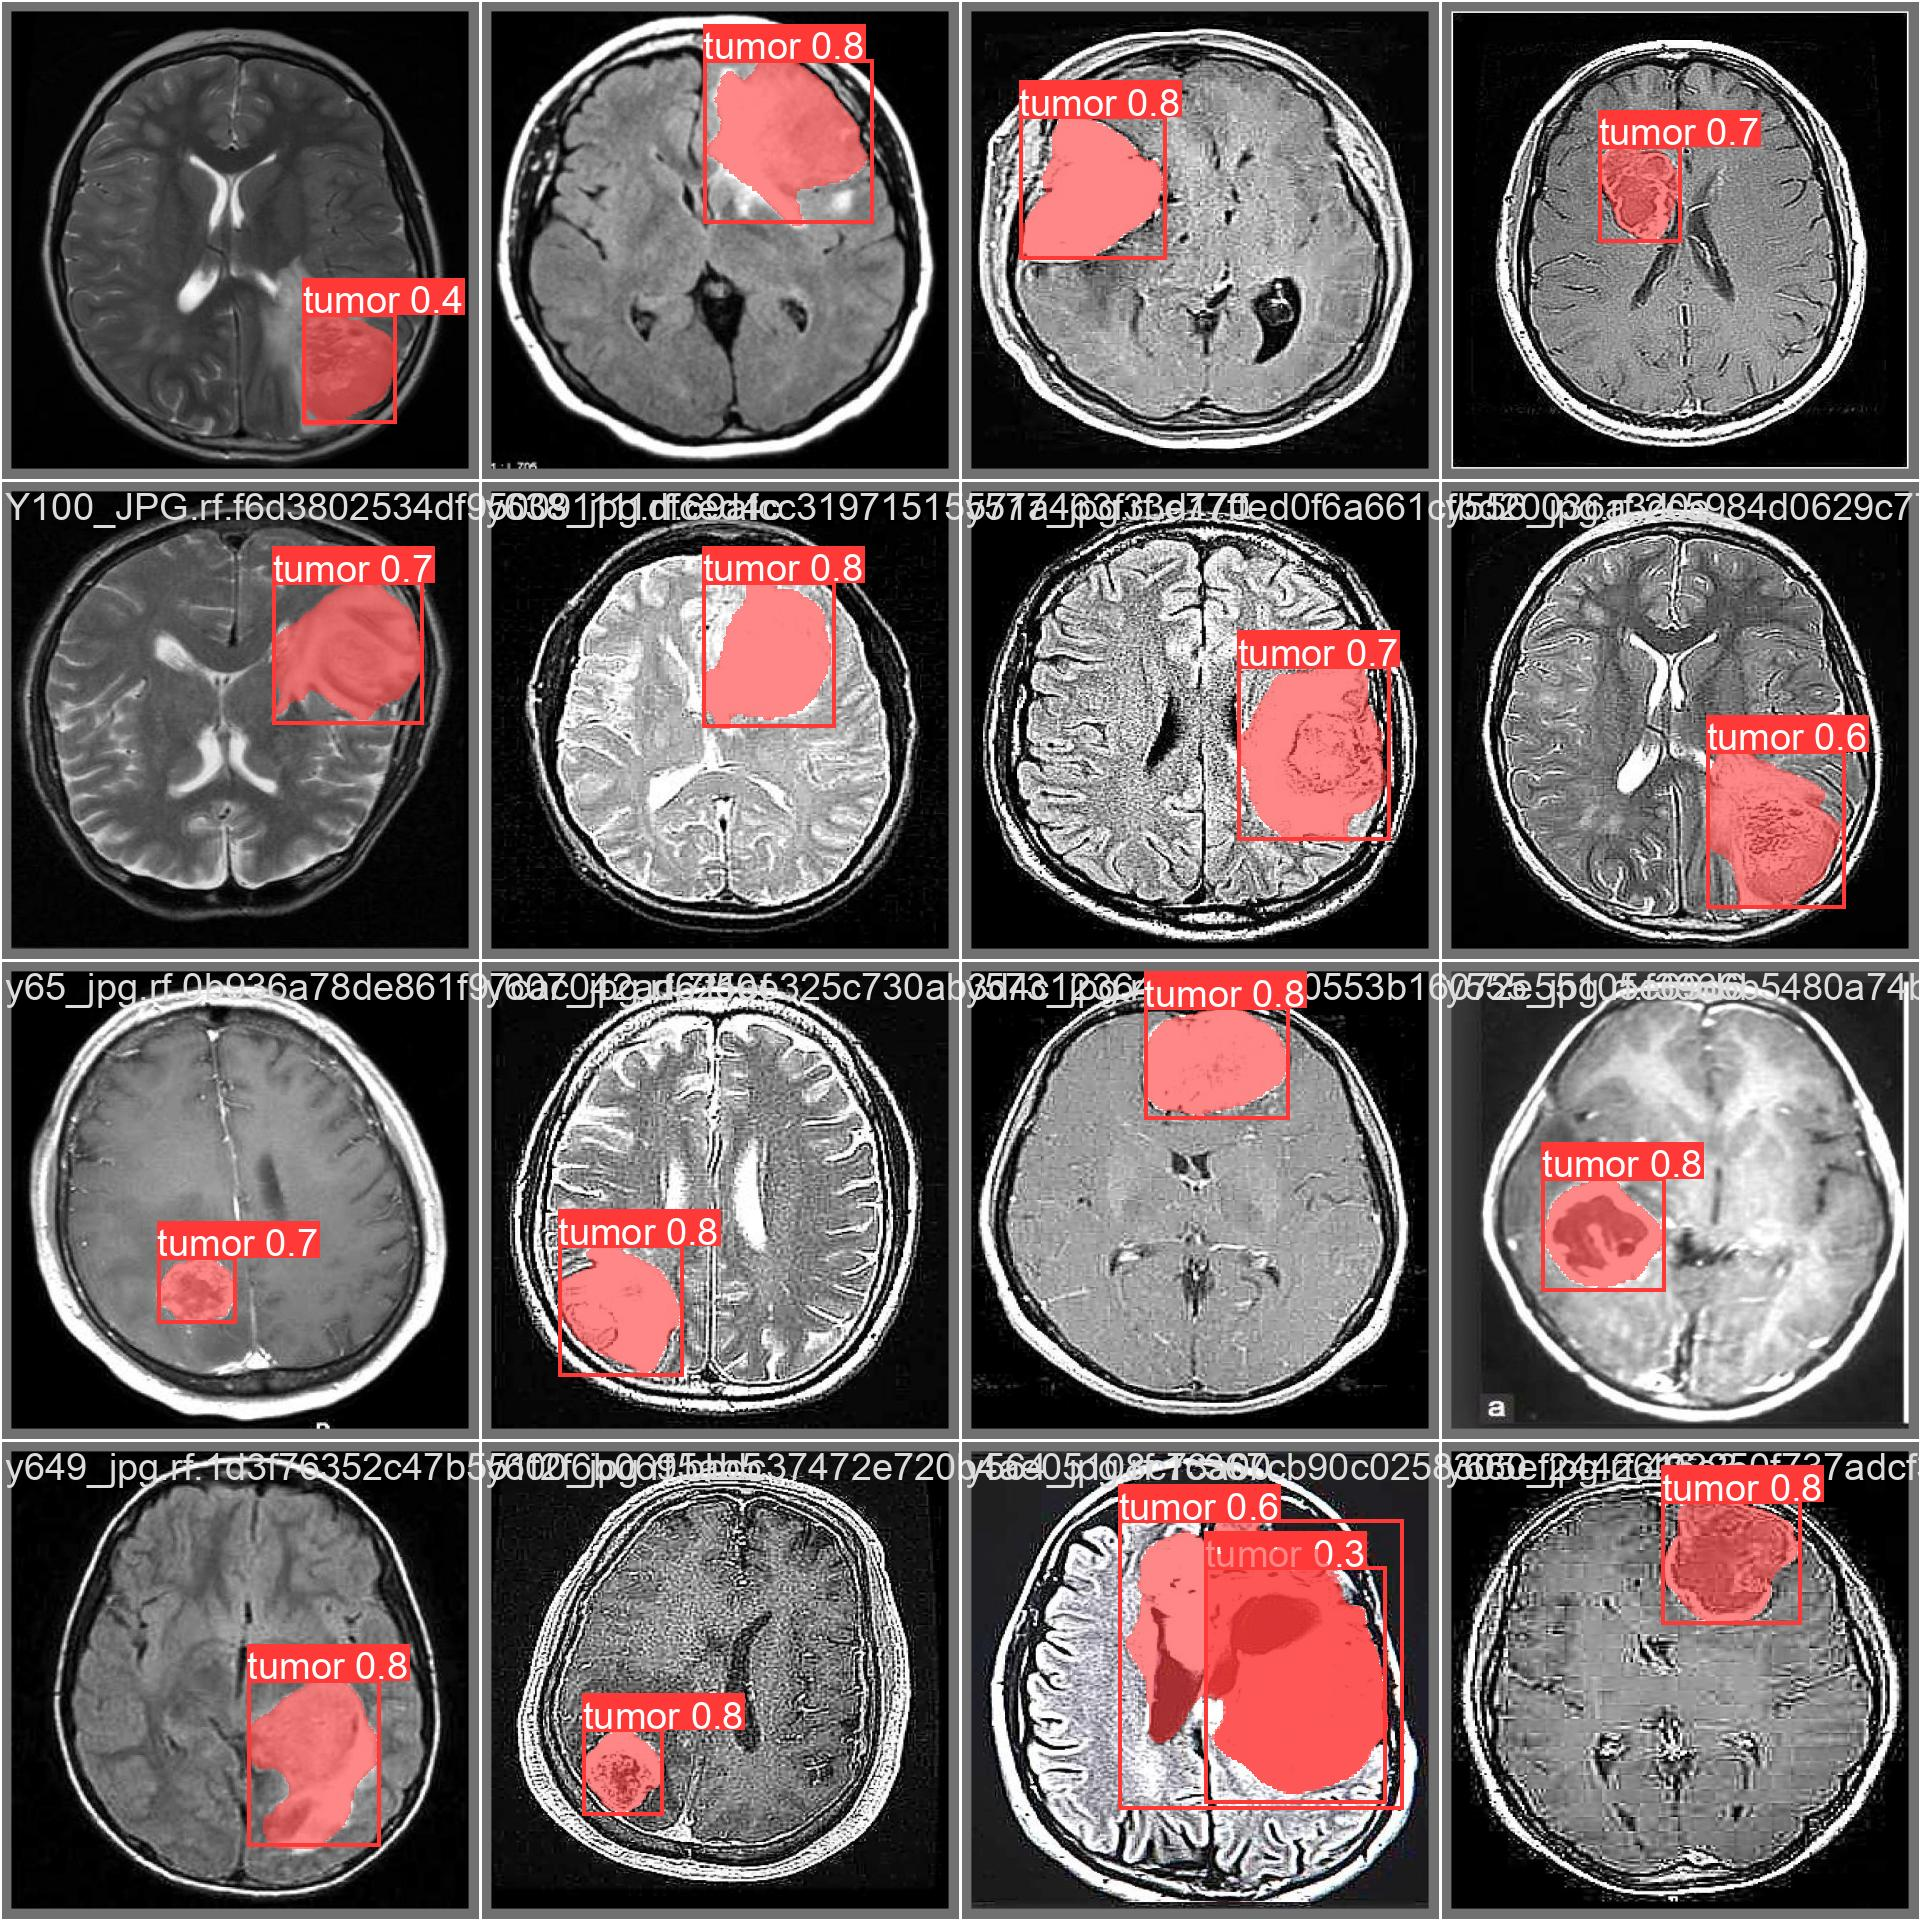

In [11]:
from IPython.display import Image, display

display(Image(filename=f"{HOME}/yolov7/seg/runs/train-seg/custom/val_batch0_pred.jpg"))

### Evaluation on test set

We can evaluate the performance of our custom training using the provided evalution script.

In [12]:
%cd {HOME}/yolov7/seg
!python segment/predict.py \
--weights {HOME}/yolov7/seg/runs/train-seg/custom/weights/best.pt \
--conf 0.25 \
--source /content/yolov7/seg/brain-tumor-detection-9/test/images

/content/yolov7/seg
segment/predict: weights=['/content/yolov7/seg/runs/train-seg/custom/weights/best.pt'], source=/content/yolov7/seg/brain-tumor-detection-9/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/predict-seg, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 2024-1-4 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 325 layers, 37842476 parameters, 0 gradients, 141.9 GFLOPs
image 1/126 /content/yolov7/seg/brain-tumor-detection-9/test/images/Y103_jpg.rf.ff5d2e99cd9f4e994d2ff648dd587726.jpg: 640x640 1 tumor, 59.5ms
image 2/126 /content/yolov7/seg/brain-tumor-detection-9/test/images/Y105_jpg.rf.e80f9be3f833607103d8b48d22edd685.jpg: 640x640 1 

No we can display results some of the results

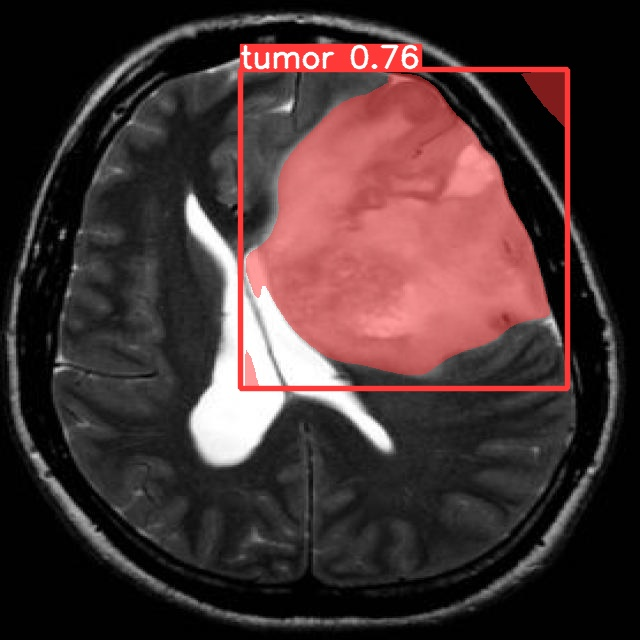

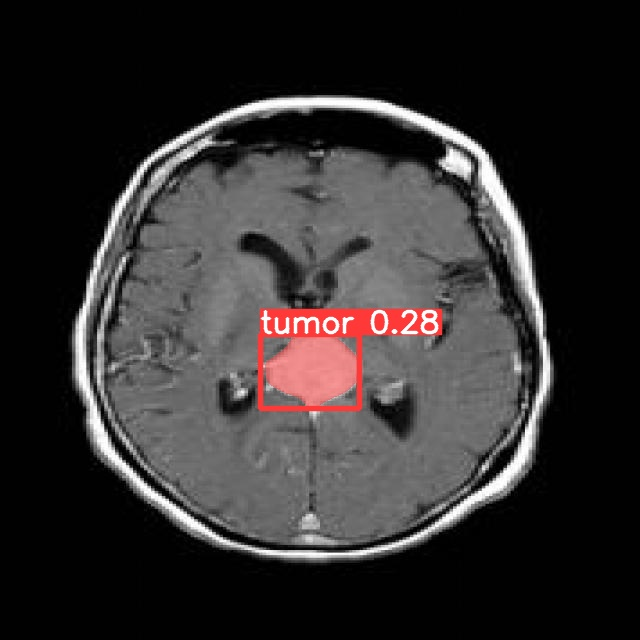

In [13]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('/content/yolov7/seg/runs/predict-seg/exp/*.jpg')[:2]:
      display(Image(filename=imageName))
      print("\n")